In [1]:
import preprocessing, modelling
incident_data = preprocessing.IncidentData.load()

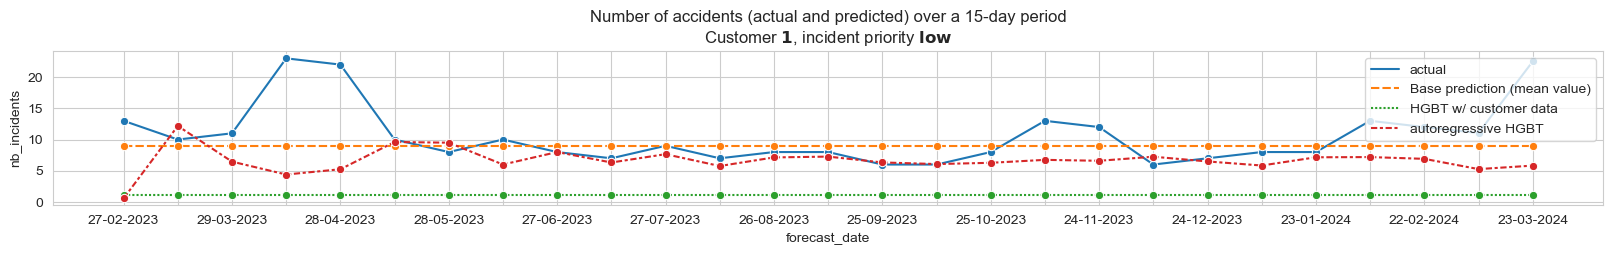

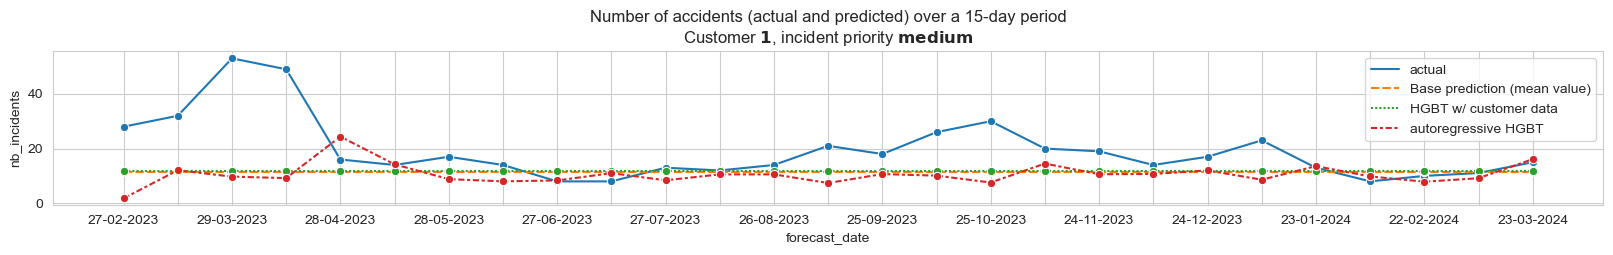

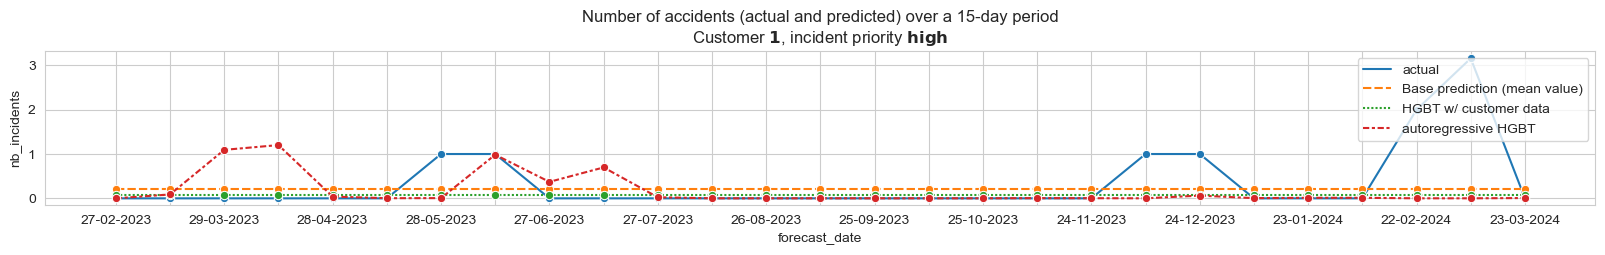

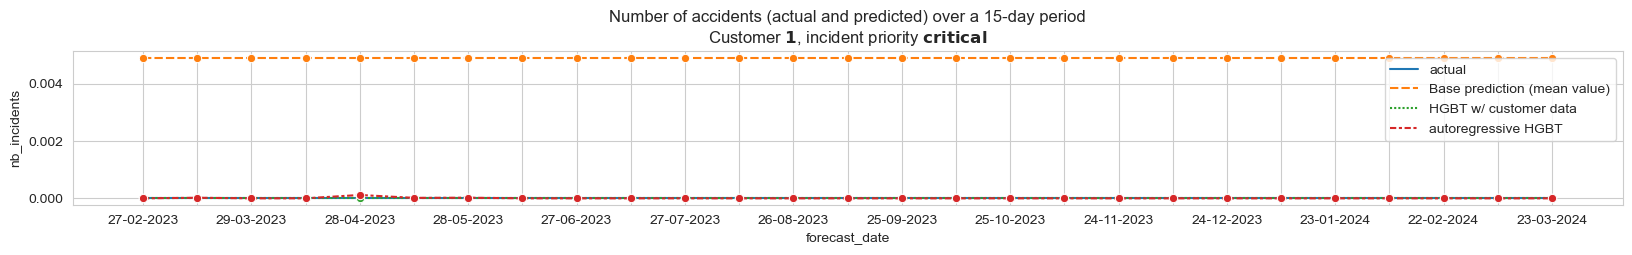

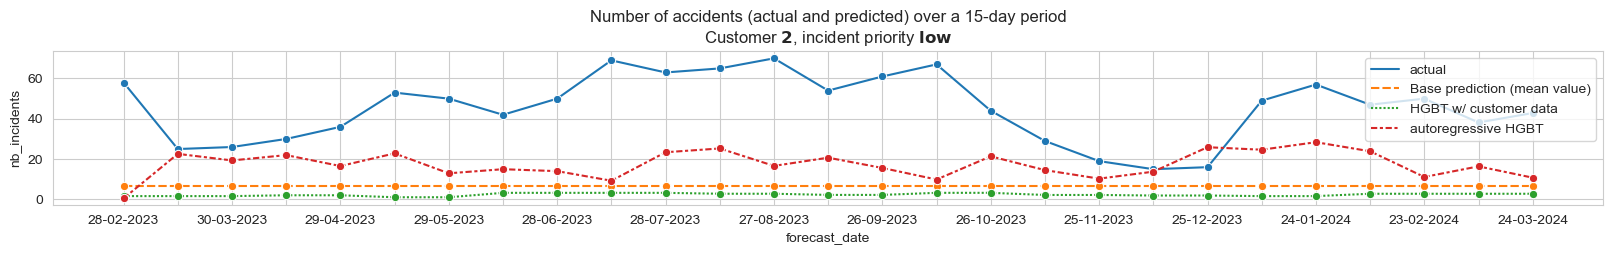

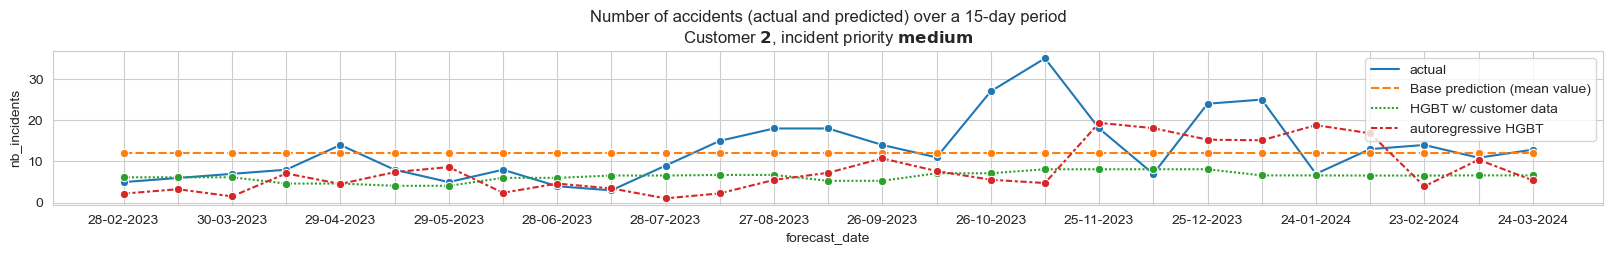

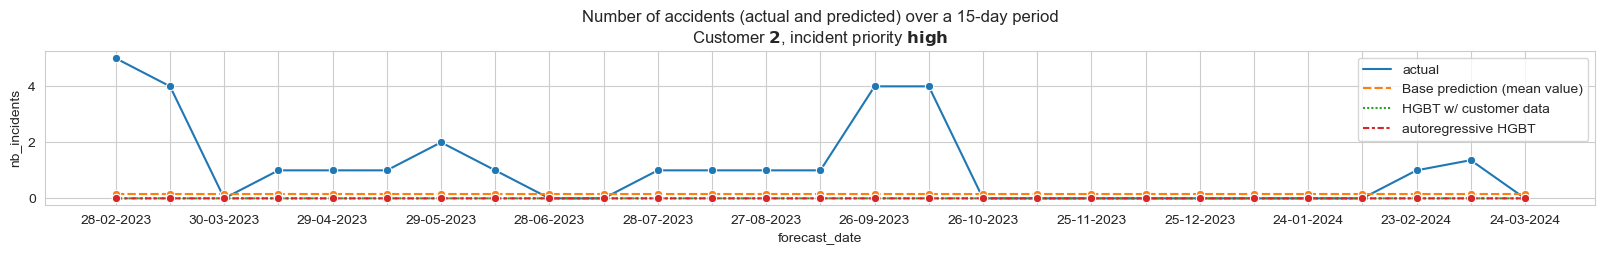

KeyboardInterrupt: 

In [133]:
import matplotlib.pyplot as plt
import seaborn 
import pandas
import modelling
import datetime
import numpy as np

# We define the models we want to test
to_test = {"Base prediction (mean value)":modelling.Parameters(), 
           "HGBT w/ customer data":modelling.Parameters(regressor="hgbt", include_range_scales=True, include_failed_logins=True,
                                                        include_fma=True, include_sectors=True, 
                                                        differencing=False, hurdle=True, regularisation=1), 
            "autoregressive HGBT":modelling.Parameters(regressor="hgbt", past_periods=(10,30, 100, 365),
                                                        differencing=True, hurdle=True, regularisation=1)}


def get_actual_time_series(customer_id, priority, time_window):
    """Return a dataframe specifying the actual nb of incidents occuring within time_window (in days), 
    for the customer and priority level"""
    
    generator = modelling.ForecastingDataGenerator(incident_data=incident_data)

    # We want nont-overlapping forecasts, so we define the dates on which to run our predictions
    # as the set of dates between start and cutoff, each separated by time_window days
    forecasting_dates = []
    for i in range(0, 3650,time_window):
        forecasting_date = generator.start_dates[customer_id] + datetime.timedelta(days=i-1)
        if forecasting_date < generator.cutoff_dates[customer_id]:
            forecasting_dates.append(forecasting_date)
        else:
            break

    # We get the actual number of incidents for the customer and priority level, for the selected dates 
    _, y_test, _ = generator.generate(priority, customer_ids=[customer_id], selected_dates=forecasting_dates)
    actual_df = pandas.DataFrame.from_dict({"forecast_date":forecasting_dates, "nb_incidents":y_test, "type":"actual"})
    return actual_df


def get_forecast_time_series(customer_id, priority, forecasting_dates, time_window):
    """Returns a set of dataframes (one per model) indicating the number of incidents predicted by the model
    for the given forecast period (in days), for the customer and priority level"""

    forecast_dfs = []
    
    # We produce a dataframe for each model in to_test
    for desc, param in to_test.items():
        
        # We define the forecast period for the model
        param.forecast_period = time_window
        if param.differencing and time_window not in param.past_periods:
            param.past_periods = (time_window, *param.past_periods)

        # We derive the training data (all customers except the one to test)
        generator = modelling.ForecastingDataGenerator(incident_data=incident_data, parameters=param)
        X_train, y_train, w_train = generator.generate(priority, customers_to_skip=[customer_id])

        # We train the forecaster
        forecaster = modelling.Forecaster(param)
        forecaster.train_for_priority(priority, X_train, y_train, w_train)

        # We derive the testing data (only for the selected dates) and run the model on those
        X_test, _, _ = generator.generate(priority, customer_ids=[customer_id], selected_dates=forecasting_dates)
        forecasts = forecaster.predict(X_test, priorities=[priority])[priority]["mean"]

        # We create a dataframe summarising the results
        forecast_df = pandas.DataFrame.from_dict({"forecast_date":forecasting_dates, "nb_incidents":forecasts, "type":desc})
        forecast_dfs.append(forecast_df)
    return forecast_dfs


def display_time_series(customer_ids=None, priorities=None, time_window=15):
    """Display the time series comparing the number of actual incidents occurring within a specified time
    window (in days). Each combination of customer and priority level leads to a separate figure"""

    customer_ids = sorted(incident_data.customers) if customer_ids is None else customer_ids
    priorities = ["low", "medium", "high", "critical"] if priorities is None else priorities

    for customer_id in customer_ids:

            for priority in priorities:
                
                # Getting the dataframes for the actual and p
                actual_df = get_actual_time_series(customer_id, priority, time_window)
                forecast_dfs = get_forecast_time_series(customer_id, priority, actual_df.forecast_date, time_window)
                all_df = pandas.concat((actual_df,*forecast_dfs))

                # Creates the plot
                fig, ax = plt.subplots(figsize=(20, 2))
                seaborn.lineplot(data=all_df, x="forecast_date", y="nb_incidents", marker="o", ax=ax, style="type", hue="type")
                all_ticks = all_df["forecast_date"].unique()
                ax.set_xticks(all_ticks)
                
                # Enrich the plot
                hop_size=2
                labels = [pandas.to_datetime(date).strftime('%d-%m-%Y') if i % hop_size == 0 else '' for i, date in enumerate(all_ticks)]
                ax.set_xticklabels(labels)
                ax.legend(loc='upper right')
                ax.set_title("Number of accidents (actual and predicted) over a %i-day period\n"%(time_window) + 
                             "Customer $\\bf{%i}$, incident priority $\\bf{%s}$"%(customer_id, priority))
                plt.show()

display_time_series()

        

In [134]:
df = get_actual_time_series(2, "low", 30)
df.head(10)


,forecast_date,nb_incidents,type
0,2023-02-28,58.0,actual
1,2023-03-30,26.0,actual
2,2023-04-29,36.0,actual
3,2023-05-29,50.0,actual
4,2023-06-28,50.0,actual
5,2023-07-28,63.0,actual
6,2023-08-27,70.0,actual
7,2023-09-26,61.0,actual
8,2023-10-26,44.0,actual
9,2023-11-25,19.0,actual


In [ ]:
#X_test, _, _ = generator.generate("low", customer_ids=[3], selected_dates=df.forecast_date)
param = to_test["autoregressive HGBT"]
param.regularisation = 70
forecaster = modelling.Forecaster(param)
generator = modelling.ForecastingDataGenerator(incident_data=incident_data, parameters=param)
        
X_train, y_train, w_train = generator.generate("low", customers_to_skip=[2])

forecaster.train_for_priority(priority, X_train, y_train, w_train)

X_test, _, _ = generator.generate("low", customer_ids=[2], selected_dates=df.forecast_date)
forecasts = forecaster.predict(X_test, priorities=["low"], debug=True)["low"]

forecast_df = pandas.DataFrame.from_dict({"forecast_date":df.forecast_date, "base_output":forecasts["base_output"], "prob_zero_incidents":forecasts["prob_zero_incidents"], 
"previous_value":forecasts["previous_value"], "pred":forecasts["mean"], "actual":df.nb_incidents, "type":desc})

forecast_df.head(10)

,forecast_date,base_output,prob_zero_incidents,previous_value,pred,actual,type
0,2023-02-28,-0.258368,0.647309,0.0,0.000000,58.0,autoregressive HGBT
1,2023-03-30,-0.330662,0.000166,25.0,24.665248,26.0,autoregressive HGBT
2,2023-04-29,-0.330662,0.000738,23.0,22.652608,36.0,autoregressive HGBT
3,2023-05-29,-0.330662,0.000214,28.0,27.663419,50.0,autoregressive HGBT
4,2023-06-28,-0.330662,0.000296,25.0,24.662038,50.0,autoregressive HGBT
5,2023-07-28,-0.330662,0.000048,35.0,34.667659,63.0,autoregressive HGBT
6,2023-08-27,-0.330662,0.000150,31.0,30.664750,70.0,autoregressive HGBT
7,2023-09-26,-0.330662,0.000215,33.0,32.662309,61.0,autoregressive HGBT
8,2023-10-26,-0.330662,0.000243,39.0,38.659937,44.0,autoregressive HGBT
9,2023-11-25,-0.330662,0.000047,16.0,15.668608,19.0,autoregressive HGBT


In [111]:
forecasts.keys()

dict_keys(['mean'])

In [ ]:
records = []
for customer_id, customer in incident_data.customers.items():
    record = {"turnover_range":customer.turnover_range_rank, "employee_range":customer.employee_range_rank}
    print(customer_id, record)
    for priority in ["low", "medium", "high", "critical"]:
        record["nb_%s_incidents"%priority] = sum([incident.priority==priority for incident in incident_data.incidents_by_customer[customer_id]])
    records.append(record)
df = pandas.DataFrame.from_records(records)
seaborn.pairplot(df, kind="reg", height=2, corner=True,  diag_kind = "hist", 
             diag_kws = {'alpha':0.55, 'bins':11})

In [3]:
import modelling, pandas
tuner = modelling.Tuner(incident_data)
records = []
tuner = modelling.Tuner(incident_data, study_name="tuning_new")
for trial in tuner.study.trials:
    record = dict(trial.params)
    record["mae"] = trial.value
    records.append(record)
trials = pandas.DataFrame.from_records(records)
trials.nb_past_periods = trials.nb_past_periods.fillna(0)

In [ ]:
trials.sort_values("mae").head(10)

In [24]:
p = modelling.Parameters(classifier="hgbt", past_periods=(10,30, 100, 365), differentiation="true", hurdle=True, regularisation=70)
forecaster = modelling.Forecaster(incident_data, p)
#print("RESULT:", forecaster.evaluate())
forecaster.train(priority="medium", customers_to_skip=[1])
forecast, y, _, lb, hb = forecaster.test(customer_id=1, priority="medium", return_true=True, return_ci=True)
for i in range(10):
    print(forecast[i], lb[i], hb[i])

17.213514389071307 2.0066394536639898 63.3096474536736
17.213514389071307 2.0066394536639898 63.3096474536736
28.982952837795914 4.543231736545724 78.43927273938351
15.0 15.0 15.0
21.440945450631013 5.523956025009447 60.881474157109615
19.256385306388893 4.4738323076649 49.572338387114
16.540987931953108 3.040442311727624 61.39119598672305
18.755266332021595 3.0234227741604958 67.14958792837234
21.462984114447636 4.267405459197233 75.52736868815603
18.706738451560437 1.94092601543219 63.4462935080794


In [ ]:
p = modelling.Parameters(include_range_scales=True, include_sectors=True, include_failed_logins=True, include_cvss=True, include_recency=True, hurdle=True, regularisation=75)
forecaster = modelling.Forecaster(incident_data, p)
#print("RESULT:", forecaster.evaluate())
forecaster.train(priority="medium")
forecast, y, _, lb, hb = forecaster.test(customer_id=1, priority="medium", return_true=True, return_ci=True)
for i in range(10):
    print(forecast[i], lb[i], hb[i])

In [ ]:
p = modelling.Parameters()
forecaster = modelling.Forecaster(incident_data, p)
forecaster.train(priority="medium")
forecast, y, _, lb, hb = forecaster.test(customer_id=1, priority="medium", return_true=True, return_ci=True)
for i in range(10):
    print(forecast[i], lb[i], hb[i])

In [ ]:
import numpy as np
generator = modelling.ForecastingDataGenerator(incident_data, modelling.Parameters(forecasting_period=365))
for priority in ["low", "medium", "high", "critical"]:
    _, y_test, _ = generator.generate(priority=priority)
    print("mean val:", np.mean(y_test))

In [ ]:
df2 = df[df.mae < 300]
for col in df2.columns:
    if col=="mae":
        continue
    if col in ['include_range_scale', 'include_one_hot_ranges', 'max_per_day', 'include_locations', 'include_sectors',
       'include_failed_logins', 'include_cvss', 'include_fma', 'include_recency', 'hurdle','differentiation']:
        print("%s: MAE without it:"%col.replace("include_", ""), 
              "%.3f (+- %.2f)"%(df2[df2[col]==False].mae.mean(), df2[df2[col]==False].mae.std()),
              "--> MAE with it:",
              "%.3f (+- %.2f)"%(df2[df2[col]==True].mae.mean(), df2[df2[col]==True].mae.std()))
print("classifier: poisson with MAE %.3f (+- %.2f), best result %.3f"%
        (df2[df2.classifier=="poisson"].mae.mean(), df2[df2.classifier=="poisson"].mae.std(), df2[df2.classifier=="poisson"].mae.min()),
        "hgbt with MAE %.3f (+- %.2f), best result %.3f"%
    (df2[df2.classifier=="hgbt"].mae.mean(), df2[df2.classifier=="hgbt"].mae.std(), df2[df2.classifier=="hgbt"].mae.min()))

In [ ]:
import seaborn
generator = modelling.ForecastingDataGenerator(incident_data, modelling.Parameters(include_fma=True))
X, y, w = [], [],[]
for p in ["low", "medium", "high", "critical"]:
    Xp, yp, wp = generator.generate(p)
    Xp = [{**r, "priority":p} for r in Xp]
    X += Xp
    y += yp
    w += wp
df = pandas.DataFrame.from_records(X)
feats = list(df.columns)
df["targets"] = y
for feat in feats:
    print(feat)
    seaborn.catplot(df, x=feat, y="targets", hue="priority", kind="box")
    break

In [ ]:
forecaster = modelling.Forecaster(incident_data, modelling.Parameters())
forecaster.evaluate()

In [ ]:
8.020263752880531, 7.794058973202819


In [ ]:
print("Poisson", np.mean([t.value for t in study.trials if t.params["classifier"]=="poisson"]))
print("hgbt", np.mean([t.value for t in study.trials if t.params["classifier"]=="hgbt"]))
for i in range(5):
    print("%.2f <= year penalty <= %.2f"%(0.5 + (i*0.1), 0.5 + (i*0.1) + 0.1), np.mean([t.value for t in study.trials if t.params["year_penalty"]>=0.5 + (i*0.1) and t.params["year_penalty"] <= 0.5 + (i*0.1) + 0.1]))

In [ ]:
#df = pandas.read_csv("..\\..\\data\\data_til_nr\\brute_force_count_anonymized.csv")
df.groupby(["customer", "severity"])["count"].mean()

In [ ]:
p = Parameters(include_range_scales=False, include_one_hot_ranges=True, include_cvss=False, include_failed_logins=True, hurdle=True, normalise=True, regularisation_strength=1000, classifier="poisson")
forecaster = Forecaster(incident_data, p)
forecaster.evaluate()

# {'include_range_scale': True, 'include_one_hot_ranges': True, 'nb_past_periods': 3, 'max_per_day': False, 'include_locations': False, 'include_sectors': True, 'include_failed_logins': True, 'include_cvss': True, 'include_fma': False, 'include_recency': True, 'year_penalty': 0.6035860916067507, 'hurdle': True, 'classifier': 'poisson'}. Best is trial 3 with value: 7.747130445303156.
#Parameters(forecasting_period=30, include_range_scales=False, include_one_hot_ranges=True, past_periods=[], max_per_day=False, include_locations=True, include_sectors=True, include_recency=False, include_failed_logins=True, include_cvss=True, include_fma=True, normalise=True, differentiation=True, hurdle=False, year_penalty=0.5426113125038903, classifier='poisson')
#{'include_range_scale': False, 'include_one_hot_ranges': True, 'nb_past_periods': 4, 'max_per_day': False, 'include_locations': True, 'include_sectors': False, 'include_failed_logins': True, 'include_cvss': True, 'include_fma': False, 'include_recency': False, 'year_penalty': 0.911038900165632, 'hurdle': False, 'differentiation': False, 'classifier': 'hgbt'}

In [ ]:

def testing():
    for to_change in ["hurdle", ("differentiation", "hurdle"), 
                      "include_range_scales", "include_one_hot_ranges", "normalise", "max_per_day", 
                      "include_locations", "include_recency", "differentiation"]:
        for classifier in ["poisson", "hgbt"]:
            print("Testing", to_change, "and", classifier)
            p = Parameters()
            if type(to_change)==tuple:
                for to_change2 in to_change:
                    setattr(p, to_change2, True)
            else:
                setattr(p, to_change, True)
            print(dataclasses.asdict(p))
            forecaster = Forecaster(incident_data, p)
            r = forecaster.evaluate()

forecaster = Forecaster(incident_data, Parameters(past_periods=(10,30), include_locations=True, classifier="poisson", normalise=True))
r = forecaster.evaluate()
#testing()

In [ ]:
generator = ForecastingDataGenerator(incident_data, Parameters(include_range_scales=1))
records = []
for customer_id in incident_data.customers:
    for priority in ["all"]:
        feats, forecasts, _ = generator.generate(priority, customer_ids=[customer_id])
        records.append({"employee_range":feats[0]["employee_range_scale"], 
                        "turnover_range":feats[0]["turnover_range_scale"], 
                        "forecast":np.mean(forecasts)})
df = pandas.DataFrame.from_records(records)
import seaborn 
seaborn.pairplot(df)

In [ ]:
len(df.host.unique())